In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## کارگاه آموزشی رگرسیون غیرخطی، با مدل خطی (ماشین لرنینگ)

### گام اول : خواندن و بازبینی فایل csv

In [95]:
df = pd.read_csv("FuelConsumption.csv")
df.head(10)


,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
5,2014,ACURA,RLX,MID-SIZE,3.5,6,AS6,Z,11.9,7.7,10.0,28,230
6,2014,ACURA,TL,MID-SIZE,3.5,6,AS6,Z,11.8,8.1,10.1,28,232
7,2014,ACURA,TL AWD,MID-SIZE,3.7,6,AS6,Z,12.8,9.0,11.1,25,255
8,2014,ACURA,TL AWD,MID-SIZE,3.7,6,M6,Z,13.4,9.5,11.6,24,267
9,2014,ACURA,TSX,COMPACT,2.4,4,AS5,Z,10.6,7.5,9.2,31,212


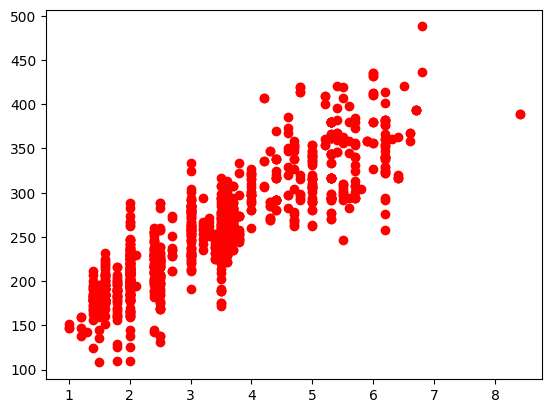

In [96]:
plt.scatter(df.ENGINESIZE , df.CO2EMISSIONS , color = "red")
plt.show()

In [97]:
msk = np.random.rand(len(df)) < 0.8
msk

array([ True,  True, False, ...,  True,  True,  True], shape=(1067,))

In [98]:
train = df[msk]
test = df[~msk]

### بخش مخصوص رگرسیون غیر خطی برای کتابخانه اس کی لرن

In [99]:
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.linear_model import LinearRegression as reg
from sklearn.metrics import r2_score as r2


### طراحی train & test

In [100]:
train_x = train[["ENGINESIZE"]]
train_y = train[["CO2EMISSIONS"]]

test_x = test[["ENGINESIZE"]]
test_y = test[["CO2EMISSIONS"]]

### معادله درجه 2 میخوام    یعنی یه ترنسفورمی انجام بده داده های درجه 1 رو به داده های درجه 2 تبدل کنه

In [101]:
poly = PolynomialFeatures(degree=3) 

### اون ترنسفورمی که انجام دادی رو فیت کن روی داده من

In [102]:
train_x_poly = poly.fit_transform(train_x)     # با این یاد بگیر
test_x_poly = poly.transform(test_x)   # اینو فقط ترنسفورم کن نمیخواد ازش یاد بگیری

### با داده جدید یادبگیر

In [103]:
model = reg()
model.fit(train_x_poly , train_y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [104]:
y_pred = model.predict(test_x_poly)

In [105]:
r2(test_y , y_pred)

0.7749587228914395

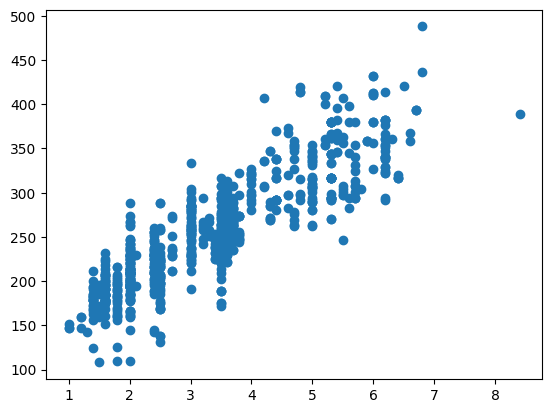

In [106]:
plt.scatter(train_x , train_y)

In [107]:
train_x_range = np.linspace(train_x.min() , train_x.max() , 100)

In [108]:
trainx_poly = poly.transform(train_x_range)

c:\Users\am.shayesteh\anaconda3\envs\PythonContinue\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [109]:
y_pred_range = model.predict(trainx_poly)

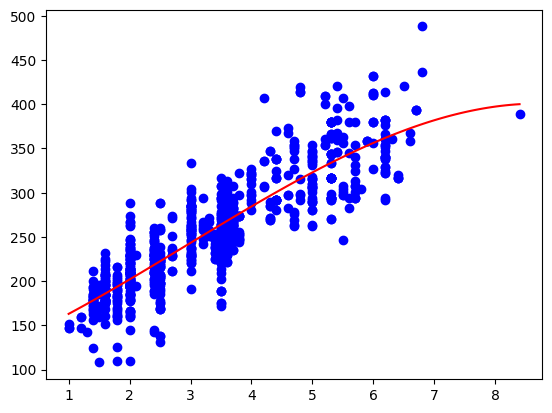

In [110]:
plt.plot(train_x_range , y_pred_range ,  color = "red" )
plt.scatter(train_x , train_y , color = "blue")
plt.show()

# بخش دوم : مدل واقعا غیر خطی !!

### ابتدا مشاهده دیتا با پانداز 

In [ ]:
df = pd.read_csv("china_gdp.csv")    # مشاهده head
df.head(10)

,Year,Value
0,1960,5.918412e+10
1,1961,4.955705e+10
2,1962,4.668518e+10
3,1963,5.009730e+10
4,1964,5.906225e+10
5,1965,6.970915e+10
6,1966,7.587943e+10
7,1967,7.205703e+10
8,1968,6.999350e+10
9,1969,7.871882e+10


In [ ]:
df.tail(10)    # مشاهده tail

,Year,Value
45,2005,2.268599e+12
46,2006,2.729784e+12
47,2007,3.523094e+12
48,2008,4.558431e+12
49,2009,5.059420e+12
50,2010,6.039659e+12
51,2011,7.492432e+12
52,2012,8.461623e+12
53,2013,9.490603e+12
54,2014,1.035483e+13
